# Case Study 2: Counterfactual Fairness in Employee Attrition

## Objective
Investigate whether mandatory overtime causally drives employee attrition, and whether
this effect is fair across genders. Using counterfactual fairness analysis, we ask:
would an employee's attrition outcome change if their gender were different, everything
else held constant?

**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)
**Treatment:** Overtime assignment (OverTime)
**Outcome:** Employee attrition (Attrition)
**Protected Attribute:** Gender
**Confounders:** Age, JobLevel, MonthlyIncome, JobSatisfaction

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS2_Hiring\Dataset\HR-Employee-Attrition.csv")
print(df.shape)
print(df.head())
print(df.dtypes)

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore')

## 1. Exploratory Analysis
Naive comparison of attrition rates across overtime and gender groups.
Note that females are assigned overtime slightly more frequently than males --
this motivates the fairness investigation.

In [5]:
df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS2_Hiring\Dataset\HR-Employee-Attrition.csv")

# Binarize outcome
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Binarize treatment
df['OverTime'] = (df['OverTime'] == 'Yes').astype(int)

# Binarize protected attribute
df['Gender'] = (df['Gender'] == 'Male').astype(int)

# Keep relevant columns and drop missing values
df = df[['Age', 'JobLevel', 'MonthlyIncome', 'JobSatisfaction', 'Gender', 'OverTime', 'Attrition']].dropna()

print(df.shape)
print(df.head())

(1470, 7)
   Age  JobLevel  MonthlyIncome  JobSatisfaction  Gender  OverTime  Attrition
0   41         2           5993                4       0         1          1
1   49         2           5130                2       1         0          0
2   37         1           2090                3       1         1          1
3   33         1           2909                3       0         1          0
4   27         1           3468                2       1         0          0


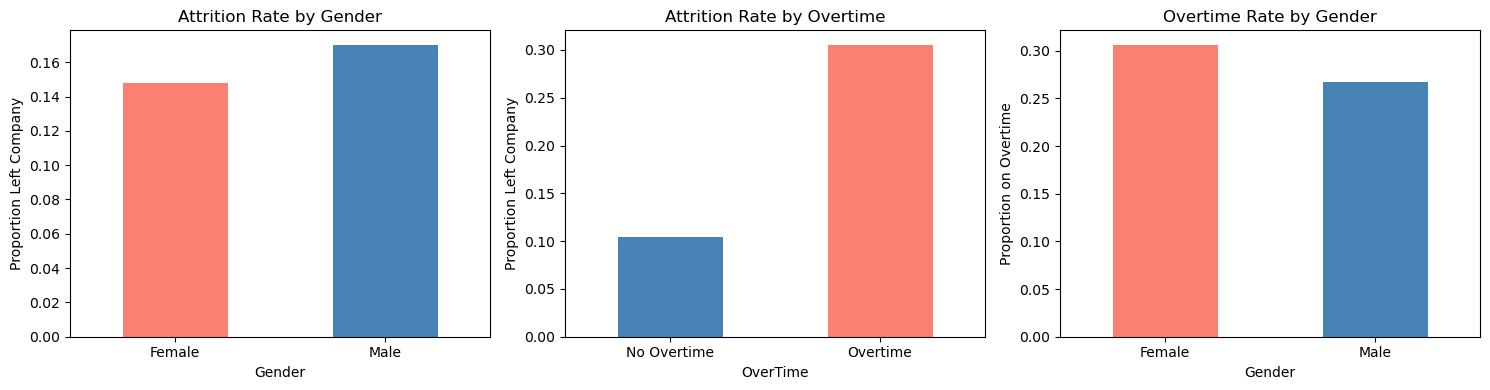

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Attrition rate by gender
df.groupby('Gender')['Attrition'].mean().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Attrition Rate by Gender')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].set_ylabel('Proportion Left Company')

# Attrition rate by overtime
df.groupby('OverTime')['Attrition'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Attrition Rate by Overtime')
axes[1].set_xticklabels(['No Overtime', 'Overtime'], rotation=0)
axes[1].set_ylabel('Proportion Left Company')

# Overtime rate by gender
df.groupby('Gender')['OverTime'].mean().plot(kind='bar', ax=axes[2], color=['salmon', 'steelblue'])
axes[2].set_title('Overtime Rate by Gender')
axes[2].set_xticklabels(['Female', 'Male'], rotation=0)
axes[2].set_ylabel('Proportion on Overtime')

plt.tight_layout()
plt.savefig(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS2_Hiring\eda_plot.png", dpi=150)
plt.show()

## 2. Causal Graph (DAG)
Gender is included as a confounder -- it affects both who gets assigned overtime
and who leaves the company. This allows us to later isolate gender-specific effects.

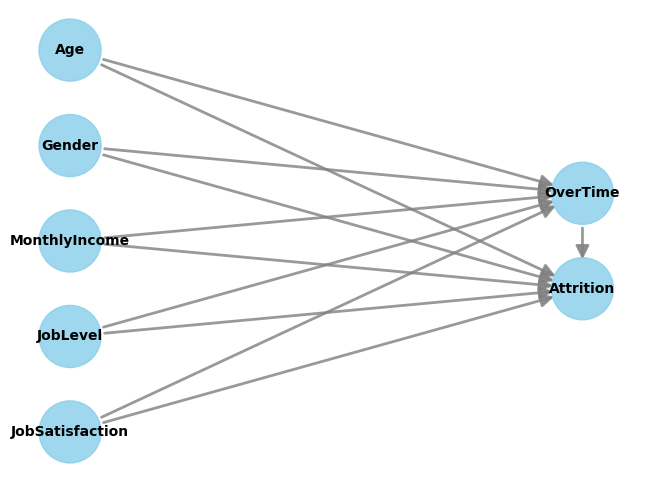

In [9]:
model = CausalModel(
    data=df,
    treatment='OverTime',
    outcome='Attrition',
    common_causes=['Age', 'JobLevel', 'MonthlyIncome', 'JobSatisfaction', 'Gender']
)

model.view_model()

## 3. Causal Identification
Backdoor criterion satisfied by conditioning on {Age, Gender, JobLevel,
MonthlyIncome, JobSatisfaction}.

In [11]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                     
───────────(E[Attrition|JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age])
d[OverTime]                                                                
Estimand assumption 1, Unconfoundedness: If U→{OverTime} and U→Attrition then P(Attrition|OverTime,JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age,U) = P(Attrition|OverTime,JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                                     
───────────(E[Attrition|JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age])
d[OverTime]                                                                
Est

## 4. Causal Effect Estimation
Average Treatment Effect (ATE) of overtime on attrition, adjusted for all confounders.

In [13]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                     
───────────(E[Attrition|JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age])
d[OverTime]                                                                
Estimand assumption 1, Unconfoundedness: If U→{OverTime} and U→Attrition then P(Attrition|OverTime,JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age,U) = P(Attrition|OverTime,JobSatisfaction,JobLevel,MonthlyIncome,Gender,Age)

## Realized estimand
b: Attrition~OverTime+JobSatisfaction+JobLevel+MonthlyIncome+Gender+Age
Target units: ate

## Estimate
Mean value: 0.20689051355324262
p-value: [6.53603893e-24]



## 5. Counterfactual Fairness Analysis
We estimate the causal effect of overtime on attrition separately for male and female
subgroups. If the effects differ significantly, overtime policy is causally unfair --
it harms one gender more than the other.

In [15]:
# Estimate causal effect separately for male and female subgroups
estimate_female = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    target_units=lambda df: df[df['Gender'] == 0],
    test_significance=True
)

estimate_male = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    target_units=lambda df: df[df['Gender'] == 1],
    test_significance=True
)

print("Causal effect of Overtime on Attrition:")
print(f"  Female: {estimate_female.value:.4f}")
print(f"  Male:   {estimate_male.value:.4f}")
print(f"  Difference (fairness gap): {abs(estimate_female.value - estimate_male.value):.4f}")

Causal effect of Overtime on Attrition:
  Female: 0.2069
  Male:   0.2069
  Difference (fairness gap): 0.0000


## 5. Counterfactual Fairness Analysis
We estimate the causal effect of overtime on attrition separately for male and female
subgroups. If the effects differ significantly, overtime policy is causally unfair --
it harms one gender more than the other.

In [17]:
# Build a second model -- now gender is treatment, overtime is outcome
# Question: does being female causally increase the probability of being assigned overtime?

model_fairness = CausalModel(
    data=df,
    treatment='Gender',
    outcome='OverTime',
    common_causes=['Age', 'JobLevel', 'MonthlyIncome', 'JobSatisfaction']
)

estimand_fairness = model_fairness.identify_effect(proceed_when_unidentifiable=True)

estimate_fairness = model_fairness.estimate_effect(
    estimand_fairness,
    method_name="backdoor.linear_regression",
    test_significance=True
)

print(estimate_fairness)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                                            
─────────(E[OverTime|Age,JobSatisfaction,MonthlyIncome,JobLevel])
d[Gender]                                                        
Estimand assumption 1, Unconfoundedness: If U→{Gender} and U→OverTime then P(OverTime|Gender,Age,JobSatisfaction,MonthlyIncome,JobLevel,U) = P(OverTime|Gender,Age,JobSatisfaction,MonthlyIncome,JobLevel)

## Realized estimand
b: OverTime~Gender+Age+JobSatisfaction+MonthlyIncome+JobLevel
Target units: ate

## Estimate
Mean value: -0.039151684452575664
p-value: [0.10342229]



## 7. Refutation Tests
Robustness checks on the main overtime -> attrition estimate.

In [19]:
# Refute the main overtime -> attrition estimate
ref1 = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
ref2 = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter", placebo_type="permute")

print("Refutation 1 - Random Common Cause:")
print(f"  Original effect: {estimate.value:.4f}")
print(f"  New effect:      {ref1.new_effect:.4f}")

print("\nRefutation 2 - Placebo Treatment:")
print(f"  Original effect: {estimate.value:.4f}")
print(f"  New effect:      {ref2.new_effect:.4f}")

Refutation 1 - Random Common Cause:
  Original effect: 0.2069
  New effect:      0.2068

Refutation 2 - Placebo Treatment:
  Original effect: 0.2069
  New effect:      -0.0015


## 8. Summary of Results

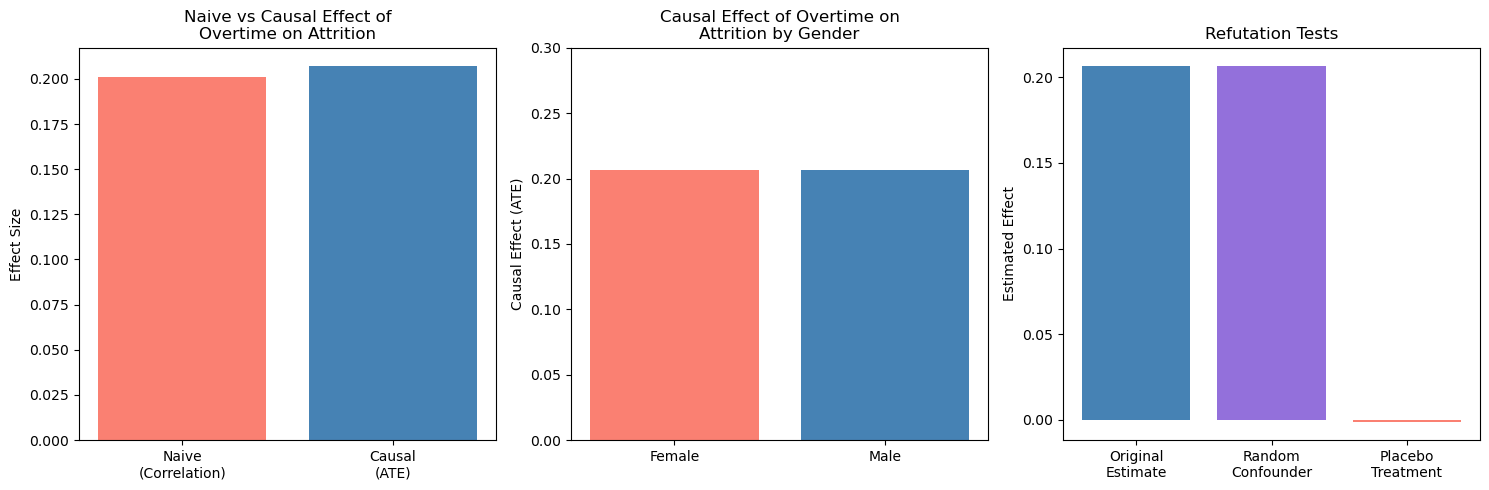

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Naive vs Causal effect of Overtime on Attrition
naive_effect = df.groupby('OverTime')['Attrition'].mean()[1] - df.groupby('OverTime')['Attrition'].mean()[0]
causal_effect = 0.2069

axes[0].bar(['Naive\n(Correlation)', 'Causal\n(ATE)'],
            [naive_effect, causal_effect],
            color=['salmon', 'steelblue'])
axes[0].set_title('Naive vs Causal Effect of\nOvertime on Attrition')
axes[0].set_ylabel('Effect Size')

# Plot 2: Gender-stratified causal effect
axes[1].bar(['Female', 'Male'],
            [estimate_female.value, estimate_male.value],
            color=['salmon', 'steelblue'])
axes[1].set_title('Causal Effect of Overtime on\nAttrition by Gender')
axes[1].set_ylabel('Causal Effect (ATE)')
axes[1].set_ylim(0, 0.3)

# Plot 3: Refutation results
axes[2].bar(['Original\nEstimate', 'Random\nConfounder', 'Placebo\nTreatment'],
            [0.2069, 0.2068, -0.0015],
            color=['steelblue', 'mediumpurple', 'salmon'])
axes[2].set_title('Refutation Tests')
axes[2].set_ylabel('Estimated Effect')

plt.tight_layout()
plt.savefig(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS2_Hiring\summary_plot.png", dpi=150)
plt.show()

In [23]:
import subprocess
import sys

subprocess.run([
    sys.executable, "-m", "nbconvert",
    "--to", "html",
    r"C:\Users\Disha Sharma\Desktop\Causal_AI\CS2_Hiring\CS2.ipynb"
], check=True)

print("HTML generated")

HTML generated
